# SECTION 1: DECLARE THE MODULES

In [5]:
import os
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')




# SECTION 2: Data import and preprocess
#Run this but dont worry if it does not make any sense Jump to SECTION 3 that is related to your HD task.

In [6]:
!pip install wget
import wget

link_to_data = 'https://raw.githubusercontent.com/SIT719/2020-S2/master/data/Week_5_NSL-KDD-Dataset/training_attack_types.txt?raw=true'
DataSet = wget.download(link_to_data)

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=8162df77166a3d0b0fec2b5258e96a5bec8a288ad9cb58f463c121dd70fa8983
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [7]:
DataSet

'training_attack_types.txt'

In [8]:
header_names = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_type', 'success_pred']


# Differentiating between nominal, binary, and numeric features

# root_shell is marked as a continuous feature in the kddcup.names
# file, but it is supposed to be a binary feature according to the
# dataset documentation

# training_attack_types.txt maps each of the 22 different attacks to 1 of 4 categories
# file obtained from http://kdd.ics.uci.edu/databases/kddcup99/training_attack_types

col_names = np.array(header_names)

nominal_idx = [1, 2, 3]
binary_idx = [6, 11, 13, 14, 20, 21]
numeric_idx = list(set(range(41)).difference(nominal_idx).difference(binary_idx))

nominal_cols = col_names[nominal_idx].tolist()
binary_cols = col_names[binary_idx].tolist()
numeric_cols = col_names[numeric_idx].tolist()

In [9]:
# training_attack_types.txt maps each of the 22 different attacks to 1 of 4 categories
# file obtained from http://kdd.ics.uci.edu/databases/kddcup99/training_attack_types

category = defaultdict(list)
category['benign'].append('normal')

with open(DataSet, 'r') as f:
    for line in f.readlines():
        attack, cat = line.strip().split(' ')
        category[cat].append(attack)

attack_mapping = dict((v,k) for k in category for v in category[k])

In [10]:
attack_mapping

{'normal': 'benign',
 'apache2': 'dos',
 'back': 'dos',
 'mailbomb': 'dos',
 'processtable': 'dos',
 'snmpgetattack': 'dos',
 'teardrop': 'dos',
 'smurf': 'dos',
 'land': 'dos',
 'neptune': 'dos',
 'pod': 'dos',
 'udpstorm': 'dos',
 'ps': 'u2r',
 'buffer_overflow': 'u2r',
 'perl': 'u2r',
 'rootkit': 'u2r',
 'loadmodule': 'u2r',
 'xterm': 'u2r',
 'sqlattack': 'u2r',
 'httptunnel': 'u2r',
 'ftp_write': 'r2l',
 'guess_passwd': 'r2l',
 'snmpguess': 'r2l',
 'imap': 'r2l',
 'spy': 'r2l',
 'warezclient': 'r2l',
 'warezmaster': 'r2l',
 'multihop': 'r2l',
 'phf': 'r2l',
 'named': 'r2l',
 'sendmail': 'r2l',
 'xlock': 'r2l',
 'xsnoop': 'r2l',
 'worm': 'probe',
 'nmap': 'probe',
 'ipsweep': 'probe',
 'portsweep': 'probe',
 'satan': 'probe',
 'mscan': 'probe',
 'saint': 'probe'}

In [11]:
#Processing Training Data

train_file='https://raw.githubusercontent.com/SIT719/2020-S2/master/data/Week_5_NSL-KDD-Dataset/KDDTrain%2B.txt'



train_df = pd.read_csv(train_file, names=header_names)

train_df['attack_category'] = train_df['attack_type'] \
                                .map(lambda x: attack_mapping[x])

train_df.drop(['success_pred'], axis=1, inplace=True)






In [12]:
#Processing test Data
test_file='https://raw.githubusercontent.com/SIT719/2020-S2/master/data/Week_5_NSL-KDD-Dataset/KDDTest%2B.txt'

test_df = pd.read_csv(test_file, names=header_names)
test_df['attack_category'] = test_df['attack_type'] \
                                .map(lambda x: attack_mapping[x])
test_df.drop(['success_pred'], axis=1, inplace=True)

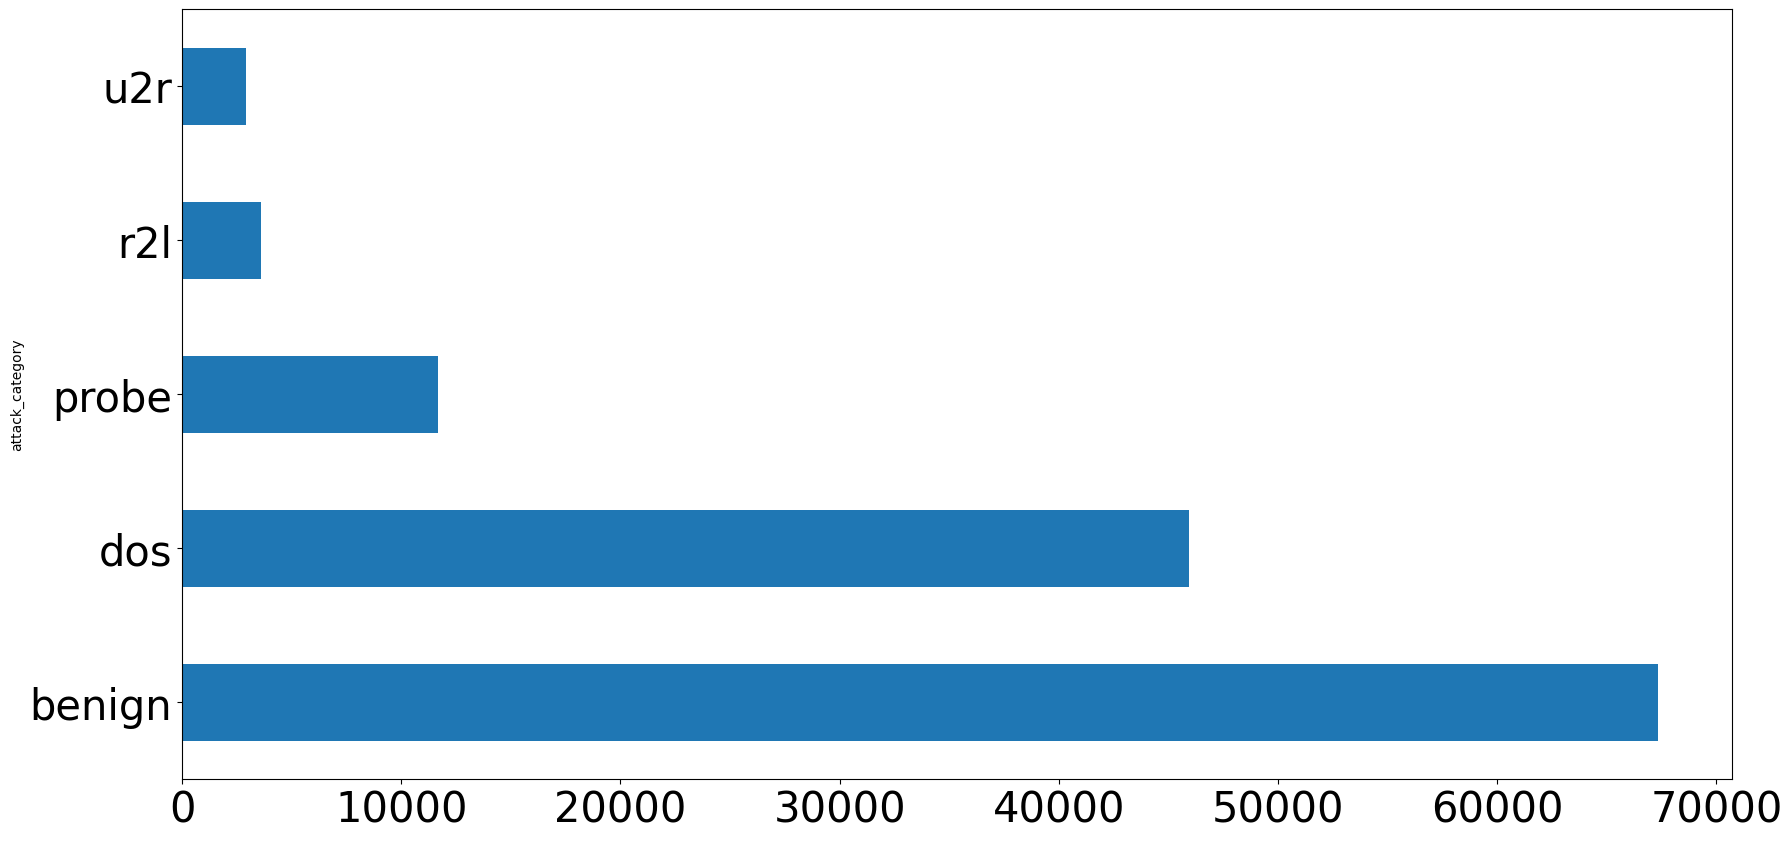

In [13]:
train_attack_types = train_df['attack_type'].value_counts()
train_attack_cats = train_df['attack_category'].value_counts()

test_attack_types = test_df['attack_type'].value_counts()
test_attack_cats = test_df['attack_category'].value_counts()

train_attack_types.plot(kind='barh', figsize=(20,10), fontsize=20)

train_attack_cats.plot(kind='barh', figsize=(20,10), fontsize=30)

train_df[binary_cols].describe().transpose()
train_df.groupby(['su_attempted']).size()
train_df['su_attempted'].replace(2, 0, inplace=True)
test_df['su_attempted'].replace(2, 0, inplace=True)
train_df.groupby(['su_attempted']).size()
train_df.groupby(['num_outbound_cmds']).size()

#Now, that's not a very useful feature - let's drop it from the dataset

train_df.drop('num_outbound_cmds', axis = 1, inplace=True)
test_df.drop('num_outbound_cmds', axis = 1, inplace=True)
numeric_cols.remove('num_outbound_cmds')



#Data Preparation

train_Y = train_df['attack_category']
train_x_raw = train_df.drop(['attack_category','attack_type'], axis=1)
test_Y = test_df['attack_category']
test_x_raw = test_df.drop(['attack_category','attack_type'], axis=1)


combined_df_raw = pd.concat([train_x_raw, test_x_raw])
combined_df = pd.get_dummies(combined_df_raw, columns=nominal_cols, drop_first=True)

train_x = combined_df[:len(train_x_raw)]
test_x = combined_df[len(train_x_raw):]

# Store dummy variable feature names
dummy_variables = list(set(train_x)-set(combined_df_raw))

#execute the commands in console
train_x.describe()
train_x['duration'].describe()
# Experimenting with StandardScaler on the single 'duration' feature
from sklearn.preprocessing import StandardScaler

durations = train_x['duration'].values.reshape(-1, 1)
standard_scaler = StandardScaler().fit(durations)
scaled_durations = standard_scaler.transform(durations)
pd.Series(scaled_durations.flatten()).describe()

# Experimenting with MinMaxScaler on the single 'duration' feature
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler().fit(durations)
min_max_scaled_durations = min_max_scaler.transform(durations)
pd.Series(min_max_scaled_durations.flatten()).describe()

# Experimenting with RobustScaler on the single 'duration' feature
from sklearn.preprocessing import RobustScaler

min_max_scaler = RobustScaler().fit(durations)
robust_scaled_durations = min_max_scaler.transform(durations)
pd.Series(robust_scaled_durations.flatten()).describe()

# Experimenting with MaxAbsScaler on the single 'duration' feature
from sklearn.preprocessing import MaxAbsScaler

max_Abs_scaler = MaxAbsScaler().fit(durations)
robust_scaled_durations = max_Abs_scaler.transform(durations)
pd.Series(robust_scaled_durations.flatten()).describe()

# Let's proceed with StandardScaler- Apply to all the numeric columns

standard_scaler = StandardScaler().fit(train_x[numeric_cols])

train_x[numeric_cols] = \
    standard_scaler.transform(train_x[numeric_cols])

test_x[numeric_cols] = \
    standard_scaler.transform(test_x[numeric_cols])

train_x.describe()



train_Y_bin = train_Y.apply(lambda x: 0 if x is 'benign' else 1)
test_Y_bin = test_Y.apply(lambda x: 0 if x is 'benign' else 1)


# SECTION 3: Multi class classification
#This is the section where you have to add other algorithms, tune algorithms and visualize to compare and analyze algorithms

In [14]:
# 5-class classification version
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, zero_one_loss

classifier = DecisionTreeClassifier(random_state=17)
classifier.fit(train_x, train_Y)

pred_y = classifier.predict(test_x)

results = confusion_matrix(test_Y, pred_y)
error = zero_one_loss(test_Y, pred_y)

print(results)
print(error)


[[9365   56  289    1    0]
 [1541 5998   97    0    0]
 [ 677  220 1526    0    0]
 [2278    1   14  277    4]
 [ 175    0    5    5   15]]
0.2378903477643719


In [15]:
# Additional algorithms for multi-class classification

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

# Define the class order for NSL-KDD
class_labels = ['benign', 'dos', 'probe', 'r2l', 'u2r']

# Define the classification algorithms
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=17),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=17),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=17),
    "Support Vector Machine": LinearSVC(random_state=17, max_iter=5000)
}

print("Models are ready:")
for name in models.keys():
    print("-", name)

Models are ready:
- Decision Tree
- Random Forest
- K-Nearest Neighbours
- Naive Bayes
- Logistic Regression
- Support Vector Machine


In [16]:
# Train and evaluate each algorithm on the NSL-KDD test dataset

all_results = {}
summary_results = []

for model_name, model in models.items():
    print("=" * 80)
    print("Algorithm:", model_name)
    print("=" * 80)

    # Train the model
    model.fit(train_x, train_Y)

    # Predict on the test dataset
    pred_y = model.predict(test_x)

    # Confusion matrix
    cm = confusion_matrix(test_Y, pred_y, labels=class_labels)
    print("Confusion Matrix:")
    print(cm)

    # Precision, Recall, F1-score for each class
    precision, recall, f1, support = precision_recall_fscore_support(
        test_Y,
        pred_y,
        labels=class_labels,
        zero_division=0
    )

    # Calculate False Positive Rate for each class
    fpr_list = []
    for i, label in enumerate(class_labels):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - (TP + FP + FN)

        fpr = FP / (FP + TN) if (FP + TN) != 0 else 0
        fpr_list.append(fpr)

    # Create class-level table
    class_table = pd.DataFrame({
        "Attack Class": class_labels,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1-Score (%)": f1 * 100,
        "False Alarm / FPR (%)": np.array(fpr_list) * 100,
        "Support": support
    })

    display(class_table)

    # Overall measures
    accuracy = accuracy_score(test_Y, pred_y)
    avg_precision = np.mean(precision)
    avg_recall = np.mean(recall)
    avg_f1 = np.mean(f1)
    avg_fpr = np.mean(fpr_list)

    summary_results.append({
        "Algorithm": model_name,
        "Accuracy (%)": accuracy * 100,
        "Average Precision (%)": avg_precision * 100,
        "Average Recall (%)": avg_recall * 100,
        "Average F1-Score (%)": avg_f1 * 100,
        "Average False Alarm / FPR (%)": avg_fpr * 100
    })

    all_results[model_name] = {
        "confusion_matrix": cm,
        "class_table": class_table,
        "predictions": pred_y
    }

Algorithm: Decision Tree
Confusion Matrix:
[[9365   56  289    1    0]
 [1541 5998   97    0    0]
 [ 677  220 1526    0    0]
 [2278    1   14  277    4]
 [ 175    0    5    5   15]]


,Attack Class,Precision (%),Recall (%),F1-Score (%),False Alarm / FPR (%),Support
0,benign,66.721288,96.437030,78.873121,36.398348,9711
1,dos,95.585657,78.548979,86.233916,1.858063,7636
2,probe,79.026411,62.979777,70.096463,2.012822,2423
3,r2l,97.879859,10.761461,19.390970,0.030045,2574
4,u2r,78.947368,7.500000,13.698630,0.017902,200


Algorithm: Random Forest
Confusion Matrix:
[[9457   67  186    0    1]
 [1582 5929  125    0    0]
 [ 807  164 1452    0    0]
 [2478    0    2   93    1]
 [ 196    0    0    3    1]]


,Attack Class,Precision (%),Recall (%),F1-Score (%),False Alarm / FPR (%),Support
0,benign,65.130854,97.384409,78.057034,39.452973,9711
1,dos,96.250000,77.645364,85.952450,1.549504,7636
2,probe,82.266289,59.925712,69.340974,1.555589,2423
3,r2l,96.875000,3.613054,6.966292,0.015023,2574
4,u2r,33.333333,0.500000,0.985222,0.008951,200


Algorithm: K-Nearest Neighbours
Confusion Matrix:
[[9444   54  207    5    1]
 [1630 5925   81    0    0]
 [ 614  180 1629    0    0]
 [2362    2   40  170    0]
 [ 170    0   17    4    9]]


...

,Attack Class,Precision (%),Recall (%),F1-Score (%),False Alarm / FPR (%),Support
0,benign,52.921824,69.570590,60.114784,46.832385,9711
1,dos,88.521837,41.409115,56.423983,2.750201,7636
2,probe,92.217899,9.781263,17.686567,0.099399,2423
3,r2l,18.971126,36.247086,24.906567,19.954932,2574
4,u2r,6.110572,31.500000,10.235581,4.332259,200


Algorithm: Logistic Regression
Confusion Matrix:
[[9004  302  401    2    2]
 [1690 5937    9    0    0]
 [ 535  110 1753   25    0]
 [2526    3    1   44    0]
 [ 182    4    0    2   12]]


,Attack Class,Precision (%),Recall (%),F1-Score (%),False Alarm / FPR (%),Support
0,benign,64.605008,92.719596,76.150203,38.439959,9711
1,dos,93.407804,77.750131,84.862779,2.810572,7636
2,probe,81.007394,72.348329,76.433399,2.042642,2423
3,r2l,60.273973,1.709402,3.324518,0.145218,2574
4,u2r,85.714286,6.000000,11.214953,0.008951,200


Algorithm: Support Vector Machine
Confusion Matrix:
[[9010   97  601    1    2]
 [1777 5849   10    0    0]
 [ 722  119 1491   91    0]
 [2481    1    1   91    0]
 [ 181    2    0    5   12]]


,Attack Class,Precision (%),Recall (%),F1-Score (%),False Alarm / FPR (%),Support
0,benign,63.580552,92.781382,75.454317,40.216629,9711
1,dos,96.390903,76.597695,85.361938,1.469010,7636
2,probe,70.898716,61.535287,65.885992,3.041598,2423
3,r2l,48.404255,3.535354,6.589428,0.485729,2574
4,u2r,85.714286,6.000000,11.214953,0.008951,200


In [17]:
# Create summary comparison table for all algorithms

summary_table = pd.DataFrame(summary_results)

# Round values for easier reading
summary_table = summary_table.round(2)

display(summary_table)

,Algorithm,Accuracy (%),Average Precision (%),Average Recall (%),Average F1-Score (%),Average False Alarm / FPR (%)
0,Decision Tree,76.21,83.63,51.25,53.66,8.06
1,Random Forest,75.11,74.77,47.81,48.26,8.52
2,K-Nearest Neighbours,76.19,86.02,50.64,51.97,8.11
3,Naive Bayes,49.46,51.75,37.70,33.87,14.79
4,Logistic Regression,74.30,77.00,50.11,50.40,8.69
5,Support Vector Machine,72.98,73.00,48.09,48.90,9.04


In [18]:
import matplotlib.pyplot as plt

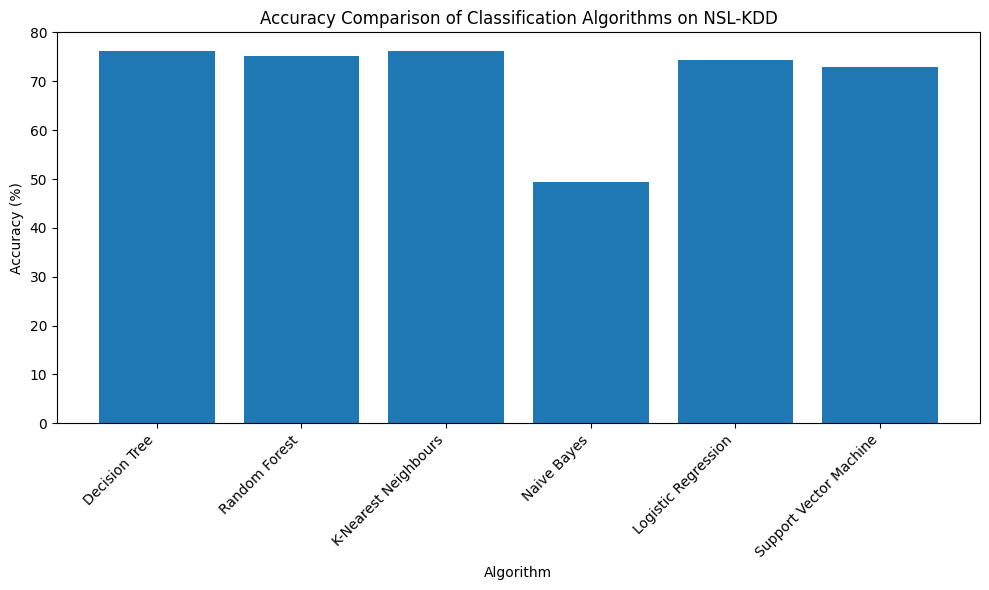

In [19]:
# Visualise and compare accuracy of different algorithms for NSL-KDD

plt.figure(figsize=(10, 6))
plt.bar(summary_table["Algorithm"], summary_table["Accuracy (%)"])

plt.title("Accuracy Comparison of Classification Algorithms on NSL-KDD")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<Figure size 700x600 with 0 Axes>

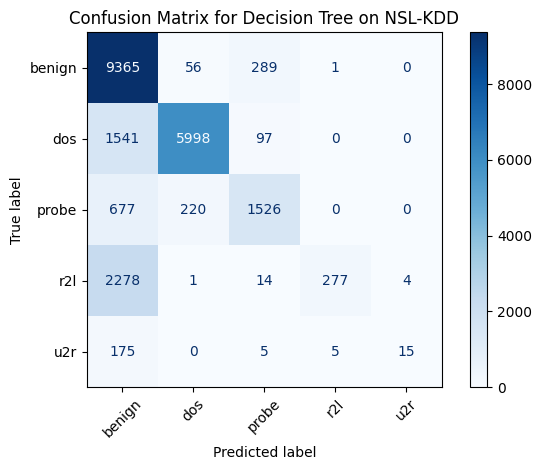

<Figure size 700x600 with 0 Axes>

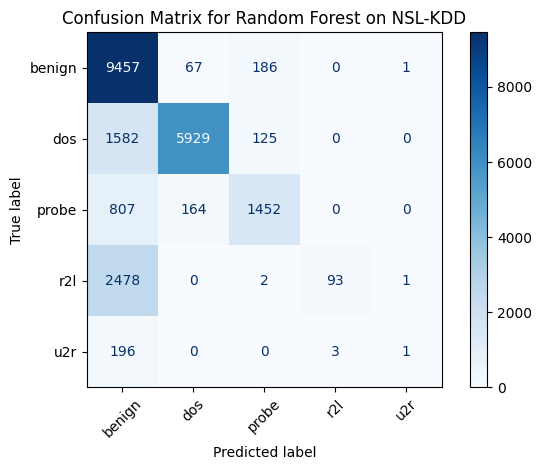

<Figure size 700x600 with 0 Axes>

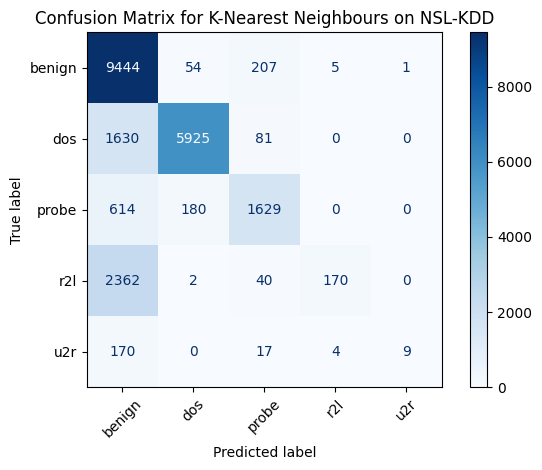

<Figure size 700x600 with 0 Axes>

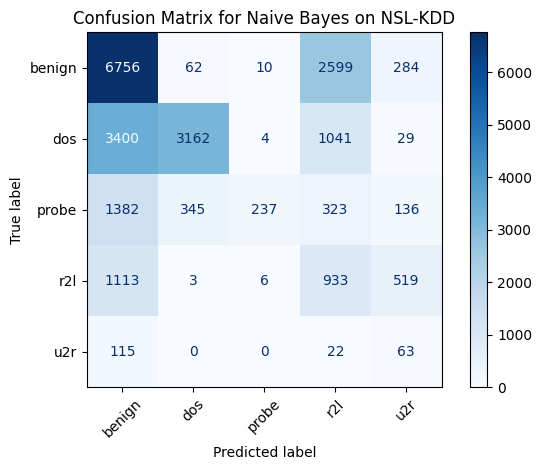

<Figure size 700x600 with 0 Axes>

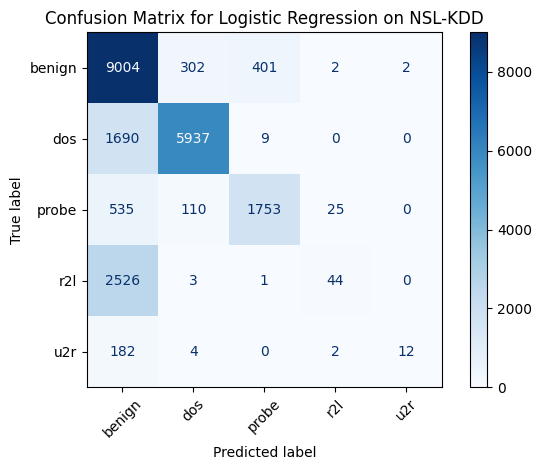

<Figure size 700x600 with 0 Axes>

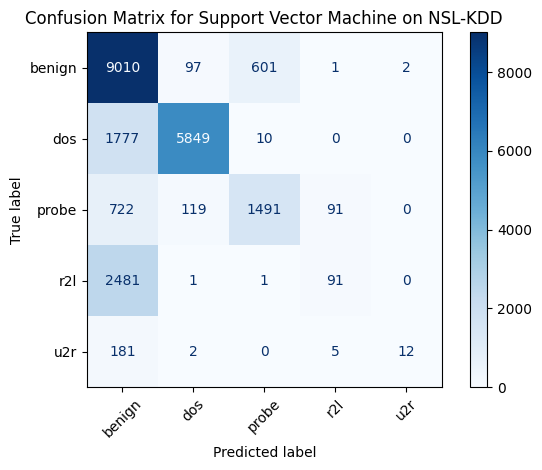

In [20]:
# Plot confusion matrices for all NSL-KDD algorithms

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for model_name, result in all_results.items():
    cm = result["confusion_matrix"]

    plt.figure(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_labels
    )
    disp.plot(values_format='d', cmap='Blues')
    plt.title(f"Confusion Matrix for {model_name} on NSL-KDD")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()